<a href="https://colab.research.google.com/github/jayantjai/Python-Learning-EDA-Project-/blob/main/SuperStore_DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

Importing the complete datashet in the excel format

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Bank_Churn_Messy.xlsx to Bank_Churn_Messy.xlsx


In [3]:
import pandas as pd
excel_file = "/content/Bank_Churn_Messy.xlsx"
xls = pd.ExcelFile(excel_file)
print(xls.sheet_names)

['Customer_Info', 'Account_Info']


In [4]:
df1 = pd.read_excel("/content/Bank_Churn_Messy.xlsx",sheet_name = "Customer_Info")

In [5]:
df2 = pd.read_excel("/content/Bank_Churn_Messy.xlsx",sheet_name = "Account_Info")

In [7]:
df1

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,French,Male,35.0,10,€101699.77
9997,15584532,Liu,709,FRA,Female,36.0,7,€42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,€92888.52
9999,15628319,Walker,792,French,Female,28.0,4,€38190.78


1. Checking Data set for EDA

In [11]:
df1.describe()

,CustomerId,CreditScore,Age,Tenure
count,1.000100e+04,10001.000000,9998.000000,10001.000000
mean,1.569093e+07,650.542946,38.920984,5.012699
std,7.193531e+04,96.658818,10.489116,2.892047
min,1.556570e+07,350.000000,18.000000,0.000000
25%,1.562852e+07,584.000000,32.000000,3.000000
50%,1.569073e+07,652.000000,37.000000,5.000000
75%,1.575323e+07,718.000000,44.000000,7.000000
max,1.581569e+07,850.000000,92.000000,10.000000


Checking datatypes of all the columns

In [ ]:
df1.dtypes

,0
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
EstimatedSalary,object


Converting the existed datatypes into correct datatypes

In [17]:
df1['EstimatedSalary'] = df1['EstimatedSalary'].str.replace('€','').astype(float)

New data type of "EstimatedSalary" column

In [19]:
df1

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,French,Female,42.0,8,113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,French,Male,35.0,10,101699.77
9997,15584532,Liu,709,FRA,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52
9999,15628319,Walker,792,French,Female,28.0,4,38190.78


In [21]:
df1.dtypes

,0
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
EstimatedSalary,float64


In [48]:
df = df1.copy()

Replacing "FRA" and "French" with "France"

In [49]:
df['Geography'] = df1['Geography'].str.replace('FRA','France',regex=False)
df['Geography'] = df1['Geography'].str.replace('French','France',regex=False)

In [50]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary
count,9.998000e+03,9998.000000,9998.000000,9998.000000,9998.000000
mean,1.569094e+07,650.559512,38.920984,5.013103,100086.031273
std,7.193356e+04,96.663450,10.489116,2.892238,57519.230467
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000
25%,1.562852e+07,584.000000,32.000000,3.000000,50973.092500
50%,1.569073e+07,652.000000,37.000000,5.000000,100218.210000
75%,1.575323e+07,718.000000,44.000000,7.000000,149395.882500
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000


Identification of duplicates.
How many times each unique value appears

In [58]:
df.value_counts()

,,,,,,,,count
CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,
15628319,Walker,792,France,Female,28.0,4,38190.78,2
15732113,Butters,671,Spain,Male,50.0,8,2560.11,1
15732175,Bruno,776,France,Male,37.0,2,8065.00,1
15732199,Gether,837,Spain,Male,31.0,9,50972.60,1
15732202,Abramovich,615,France,Male,34.0,1,73124.53,1
...,...,...,...,...,...,...,...,...
15649379,Somayina,850,France,Female,46.0,3,187980.21,1
15649414,Walker,570,France,Female,61.0,6,45214.04,1
15649418,Krylov,776,France,Female,29.0,7,115818.51,1


Removing duplicates

In [52]:
df.drop_duplicates()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,France,Female,42.0,8,113931.57
3,15701354,Boni,699,France,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39.0,5,96270.64
9996,15569892,Johnstone,516,France,Male,35.0,10,101699.77
9997,15584532,Liu,709,France,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52


Checking Null values

In [53]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
EstimatedSalary,0


Droping Null Values

In [57]:
df.dropna()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,France,Female,42.0,8,113931.57
3,15701354,Boni,699,France,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,France,Male,35.0,10,101699.77
9997,15584532,Liu,709,France,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52
9999,15628319,Walker,792,France,Female,28.0,4,38190.78


In [55]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
EstimatedSalary,0


In [56]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58
2,15619304,Onio,502,France,Female,42.0,8,113931.57
3,15701354,Boni,699,France,Female,39.0,1,93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10
...,...,...,...,...,...,...,...,...
9996,15569892,Johnstone,516,France,Male,35.0,10,101699.77
9997,15584532,Liu,709,France,Female,36.0,7,42085.58
9998,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52
9999,15628319,Walker,792,France,Female,28.0,4,38190.78


Avg Salary and Credit score (Gender Based)

In [59]:
df.groupby('Gender')[['EstimatedSalary','CreditScore']].mean().round(2)

,EstimatedSalary,CreditScore
Gender,,
Female,100592.40,650.90
Male,99664.49,650.27


Avg Salary and Credit score (Region Based)

In [60]:
df.groupby('Geography')[['EstimatedSalary', 'CreditScore']].mean().round(2)

,EstimatedSalary,CreditScore
Geography,,
France,99890.82,649.72
Germany,101113.80,651.48
Spain,99440.29,651.32


Avg Salary and Credit Score of each gender in every region

In [62]:
df.groupby(['Geography', 'Gender'])[['EstimatedSalary','CreditScore']].agg(['mean','median']).round(2)

EstimatedSalary            CreditScore       
                            mean     median        mean median
Geography Gender                                              
France    Female        99545.70   99504.03      649.30  652.0
          Male         100174.25   99017.34      650.06  653.0
Germany   Female       102448.32  104669.74      653.16  651.0
          Male          99905.03   97892.70      649.97  650.5
Spain     Female       100734.11  102889.34      651.77  653.0
          Male          98424.46   95625.03      650.98  650.0

2. Check distributions and outliers

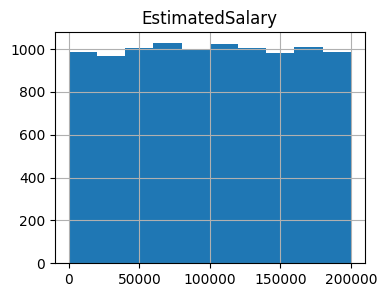

count      9998.000000
mean     100086.031273
std       57519.230467
min          11.580000
25%       50973.092500
50%      100218.210000
75%      149395.882500
max      199992.480000
Name: EstimatedSalary, dtype: float64


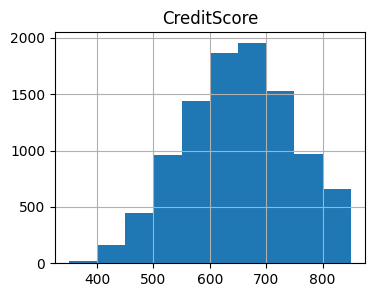

count    9998.000000
mean      650.559512
std        96.663450
min       350.000000
25%       584.000000
50%       652.000000
75%       718.000000
max       850.000000
Name: CreditScore, dtype: float64


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
list = ['EstimatedSalary','CreditScore']
for i in list:
  plt.figure(figsize=(4,3))
  df[i].hist()
  plt.title(i)
  plt.show()
  print(df[i].describe())


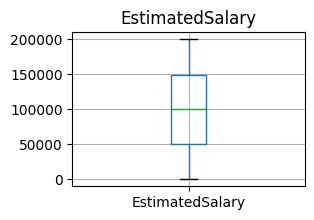

count      9998.000000
mean     100086.031273
std       57519.230467
min          11.580000
25%       50973.092500
50%      100218.210000
75%      149395.882500
max      199992.480000
Name: EstimatedSalary, dtype: float64


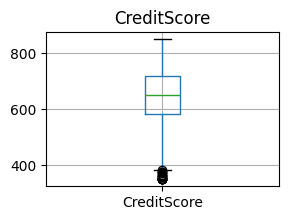

count    9998.000000
mean      650.559512
std        96.663450
min       350.000000
25%       584.000000
50%       652.000000
75%       718.000000
max       850.000000
Name: CreditScore, dtype: float64


In [75]:

list = ['EstimatedSalary','CreditScore']
for i in list:
  plt.figure(figsize= (3,2))
  df.boxplot(column =i)
  plt.title(i)
  plt.show()
  print(df[i].describe())